In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob

In [2]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43969,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35165,Total threads: 4
Dashboard: http://127.0.0.1:46627/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:46047,


2025-10-24 12:12:54,560 - distributed.nanny - WARNING - Restarting worker


In [3]:
path_atm = "/projects/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f48f2f8af20>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID
Exception ignored in: <function CachingFileManager.__del__ at 0x7f5a7e62af20>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/ni

In [20]:
Ms = 32.065 
Mair = 28.96  # dry air
Matmos = 5.3 * 10**21
K = (Ms/Mair) * Matmos *10**(-12)

Text(0.5, 1.0, 'Total SO2 concentration (global mean)')

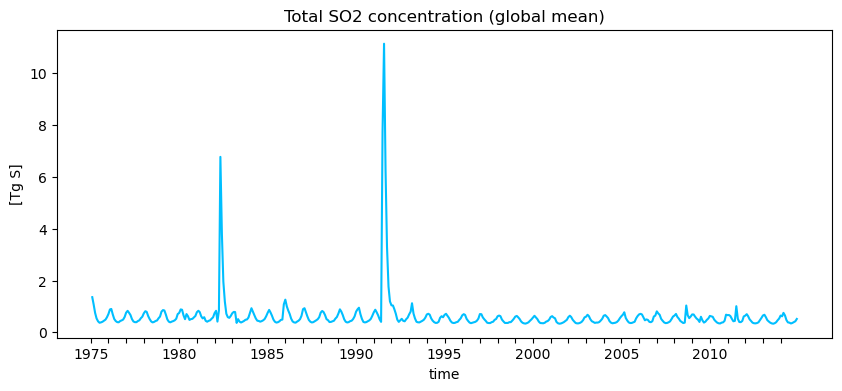

In [22]:
lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so2 = ds["SO2"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so2_tg = so2 * K

plt.figure(figsize=(10, 4))
so2_tg.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[Tg S]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Total SO2 concentration (global mean)")

Exception ignored in: <function CachingFileManager.__del__ at 0x7ff15baeb2e0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


Text(0.5, 1.0, 'Total H2SO4 concentration (global mean)')

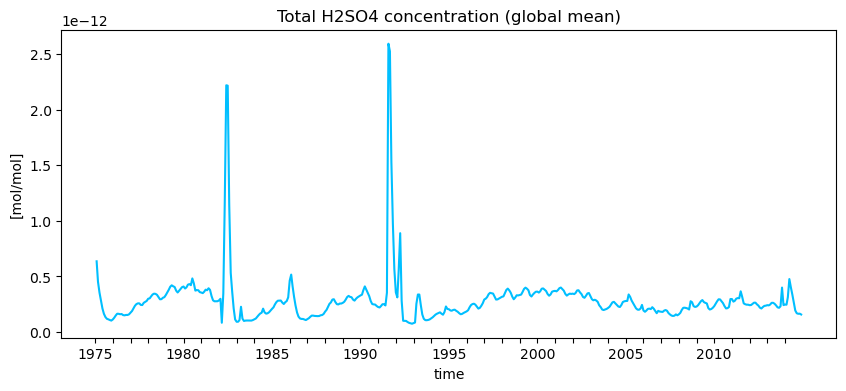

In [19]:
lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so4 = ds["H2SO4"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
#so4_tg = so4 * K

plt.figure(figsize=(10, 4))
so4.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[mol/mol]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Total H2SO4 concentration (global mean)")

In [24]:
path_obs = "/nird/projects/NS1004K/elihho/obs_pinatubo/dataset/Observation"

/tmp/ipykernel_2979551/2419528219.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  hirs_sulf_burd = pd.read_csv(f"{path_obs}/hirs_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)
/tmp/ipykernel_2979551/2419528219.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sage3l_sulf_burd = pd.read_csv(f"{path_obs}/sage3l_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)


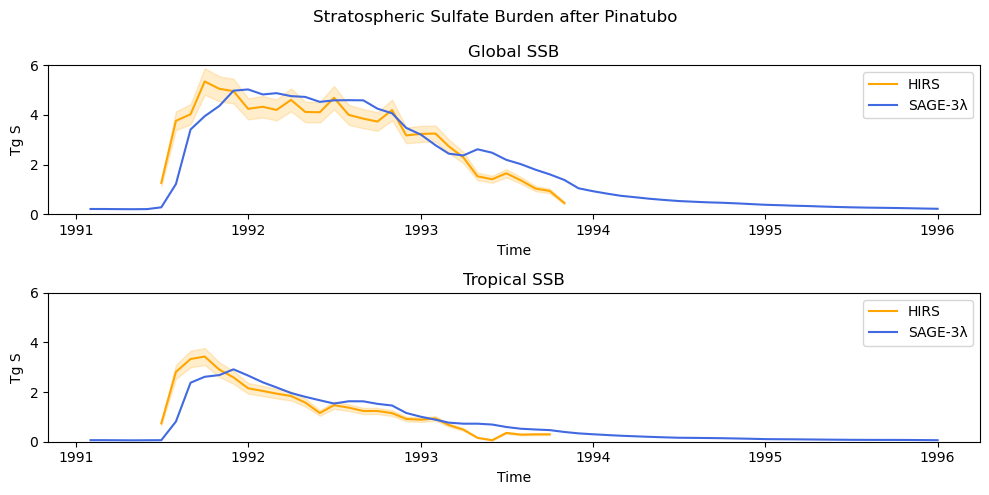

In [26]:
hirs_sulf_burd = pd.read_csv(f"{path_obs}/hirs_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)
sage3l_sulf_burd = pd.read_csv(f"{path_obs}/sage3l_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)

start = pd.Timestamp("1991-01-01")
months = [int(c) for c in hirs_sulf_burd.columns]
dates = [start + pd.DateOffset(months=m) for m in months]
hirs_sulf_burd.columns = dates

months_sage = [int(c) for c in sage3l_sulf_burd.columns]
dates_sage = [start + pd.DateOffset(months=m) for m in months_sage]
sage3l_sulf_burd.columns = dates_sage

total = hirs_sulf_burd.loc["Total_burden"].astype(float)
trop  = hirs_sulf_burd.loc["Tropical_burden"].astype(float)
err_total = hirs_sulf_burd.loc["Total_burden_error"].astype(float)
err_trop =  hirs_sulf_burd.loc["Tropical_burden_error"].astype(float)

total_sage = sage3l_sulf_burd.loc["Global"].astype(float)
trop_sage  = sage3l_sulf_burd.loc["Tropical"].astype(float)

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax[0].plot(total.index, total, color="orange", label="HIRS")
ax[0].fill_between(total.index, total - err_total, total + err_total,
                 color="orange", alpha=0.2)
ax[0].plot(total_sage.index, total_sage, color="royalblue", label="SAGE-3λ")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Tg S")
ax[0].set_ylim(0,6)
ax[0].set_title("Global SSB")
ax[0].legend()

ax[1].plot(trop.index,  trop,  color="orange", label="HIRS")
ax[1].fill_between(total.index, trop - err_trop, trop + err_trop,
                 color="orange", alpha=0.2)
ax[1].plot(trop_sage.index, trop_sage, color="royalblue", label="SAGE-3λ")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Tg S")
ax[1].set_ylim(0,6)
ax[1].set_title("Tropical SSB")
ax[1].legend()


fig.suptitle("Stratospheric Sulfate Burden after Pinatubo")
plt.tight_layout()
plt.show()
